<a href="https://colab.research.google.com/github/KaushikBose/Customer-Churn/blob/main/Task_3_feature_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Feature Engineering

---

1. Import packages
2. Load data
3. Feature engineering

---

## 1. Import packages

In [1]:
import pandas as pd

---
## 2. Load data

In [4]:
df = pd.read_csv('/Customer Churn/clean_data_after_eda.csv')
df["date_activ"] = pd.to_datetime(df["date_activ"], format='%Y-%m-%d')
df["date_end"] = pd.to_datetime(df["date_end"], format='%Y-%m-%d')
df["date_modif_prod"] = pd.to_datetime(df["date_modif_prod"], format='%Y-%m-%d')
df["date_renewal"] = pd.to_datetime(df["date_renewal"], format='%Y-%m-%d')

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
df.head(3)

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,var_6m_price_off_peak_var,var_6m_price_peak_var,var_6m_price_mid_peak_var,var_6m_price_off_peak_fix,var_6m_price_peak_fix,var_6m_price_mid_peak_fix,var_6m_price_off_peak,var_6m_price_peak,var_6m_price_mid_peak,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,0.000131,4.100838e-05,0.000908,2.086294,99.530517,44.235794,2.086425,9.953056e+01,44.236702,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,0.000003,1.217891e-03,0.000000,0.009482,0.000000,0.000000,0.009485,1.217891e-03,0.000000,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,0.000004,9.450150e-08,0.000000,0.000000,0.000000,0.000000,0.000004,9.450150e-08,0.000000,0


---

## 3. Feature engineering

### Difference between off-peak prices in December and preceding January

Below is the code created by your colleague to calculate the feature described above. Use this code to re-create this feature and then think about ways to build on this feature to create features with a higher predictive power.

In [11]:
price_df = pd.read_csv('/Customer Churn/price_data.csv')
price_df["price_date"] = pd.to_datetime(price_df["price_date"], format='%Y-%m-%d')
price_df.head()

,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.151367,0.0,0.0,44.266931,0.0,0.0
1,038af19179925da21a25619c5a24b745,2015-02-01,0.151367,0.0,0.0,44.266931,0.0,0.0
2,038af19179925da21a25619c5a24b745,2015-03-01,0.151367,0.0,0.0,44.266931,0.0,0.0
3,038af19179925da21a25619c5a24b745,2015-04-01,0.149626,0.0,0.0,44.266931,0.0,0.0
4,038af19179925da21a25619c5a24b745,2015-05-01,0.149626,0.0,0.0,44.266931,0.0,0.0


In [12]:
# Group off-peak prices by companies and month
monthly_price_by_id = price_df.groupby(['id', 'price_date']).agg({'price_off_peak_var': 'mean', 'price_off_peak_fix': 'mean'}).reset_index()

# Get january and december prices
jan_prices = monthly_price_by_id.groupby('id').first().reset_index()
dec_prices = monthly_price_by_id.groupby('id').last().reset_index()

# Calculate the difference
diff = pd.merge(dec_prices.rename(columns={'price_off_peak_var': 'dec_1', 'price_off_peak_fix': 'dec_2'}), jan_prices.drop(columns='price_date'), on='id')
diff['offpeak_diff_dec_january_energy'] = diff['dec_1'] - diff['price_off_peak_var']
diff['offpeak_diff_dec_january_power'] = diff['dec_2'] - diff['price_off_peak_fix']
diff = diff[['id', 'offpeak_diff_dec_january_energy','offpeak_diff_dec_january_power']]
diff.head()

,id,offpeak_diff_dec_january_energy,offpeak_diff_dec_january_power
0,0002203ffbb812588b632b9e628cc38d,-0.006192,0.162916
1,0004351ebdd665e6ee664792efc4fd13,-0.004104,0.177779
2,0010bcc39e42b3c2131ed2ce55246e3c,0.050443,1.500000
3,0010ee3855fdea87602a5b7aba8e42de,-0.010018,0.162916
4,00114d74e963e47177db89bc70108537,-0.003994,-0.000001


Now it is time to get creative and to conduct some of your own feature engineering! Have fun with it, explore different ideas and try to create as many as you can!

In [17]:
unique_counts = df.nunique()
constant_columns = unique_counts[unique_counts == 1].index.tolist()

print(f"Columns in df with only one unique value: {constant_columns}")

# If there are such columns, you can drop them like this:
# df = df.drop(columns=constant_columns)

# Now, let's check for columns in price_df with only one unique value
unique_counts_price = price_df.nunique()
constant_columns_price = unique_counts_price[unique_counts_price == 1].index.tolist()

print(f"Columns in price_df with only one unique value: {constant_columns_price}")

# Drop constant columns from price_df if any exist
if constant_columns_price:
    price_df = price_df.drop(columns=constant_columns_price)
    print(f"Dropped constant columns from price_df: {constant_columns_price}")

# Create new date features for df
df['date_activ_year'] = df['date_activ'].dt.year
df['date_activ_month'] = df['date_activ'].dt.month
df['date_activ_day'] = df['date_activ'].dt.day
df['date_activ_weekday'] = df['date_activ'].dt.weekday

df['date_end_year'] = df['date_end'].dt.year
df['date_end_month'] = df['date_end'].dt.month
df['date_end_day'] = df['date_end'].dt.day
df['date_end_weekday'] = df['date_end'].dt.weekday

df['date_modif_prod_year'] = df['date_modif_prod'].dt.year
df['date_modif_prod_month'] = df['date_modif_prod'].dt.month
df['date_modif_prod_day'] = df['date_modif_prod'].dt.day
df['date_modif_prod_weekday'] = df['date_modif_prod'].dt.weekday

df['date_renewal_year'] = df['date_renewal'].dt.year
df['date_renewal_month'] = df['date_renewal'].dt.month
df['date_renewal_day'] = df['date_renewal'].dt.day
df['date_renewal_weekday'] = df['date_renewal'].dt.weekday

print("\nNew date features added to df:")
print(df[['id', 'date_activ', 'date_activ_year', 'date_activ_month', 'date_activ_day', 'date_activ_weekday']].head())

# Create new date features for price_df
# price_date_year and price_date_day are already dropped if they were constant
price_df['price_date_month'] = price_df['price_date'].dt.month
price_df['price_date_weekday'] = price_df['price_date'].dt.weekday

print("\nNew date features added to price_df:")
print(price_df[['id', 'price_date', 'price_date_month', 'price_date_weekday']].head())


# Create new combined features in df
df['margin_net_pow_ele_mean'] = df.groupby(['id'])['margin_net_pow_ele'].transform('mean')
df['total_usage_12m'] = df['cons_12m'] + df['cons_gas_12m']
df['actual_vs_forecast_diff'] = df['forecast_cons_12m'] - df['cons_12m']
df['contract_duration'] = (df['date_end'] - df['date_activ']).dt.days
df['time_since_last_prod_change'] = (df['date_renewal'] - df['date_modif_prod']).dt.days

print("\nNew combined features added to df:")
print(df[['id', 'margin_net_pow_ele_mean', 'total_usage_12m', 'actual_vs_forecast_diff', 'contract_duration', 'time_since_last_prod_change']].head())

# Finally, combine the datasets
merged_df = pd.merge(df, price_df, on='id', how='left')
merged_df = pd.merge(merged_df, diff, on='id', how='left')

print("\nCombined dataset shape:", merged_df.shape)
print("Combined dataset head:")
print(merged_df.head())

Columns in df with only one unique value: []
Columns in price_df with only one unique value: ['price_date_year', 'price_date_day']
Dropped constant columns from price_df: ['price_date_year', 'price_date_day']

New date features added to df:
                                 id date_activ  date_activ_year  \
0  24011ae4ebbe3035111d65fa7c15bc57 2013-06-15             2013   
1  d29c2c54acc38ff3c0614d0a653813dd 2009-08-21             2009   
2  764c75f661154dac3a6c254cd082ea7d 2010-04-16             2010   
3  bba03439a292a1e166f80264c16191cb 2010-03-30             2010   
4  149d57cf92fc41cf94415803a877cb4b 2010-01-13             2010   

   date_activ_month  date_activ_day  date_activ_weekday  
0                 6              15                   5  
1                 8              21                   4  
2                 4              16                   4  
3                 3              30                   1  
4                 1              13                   2  

New dat

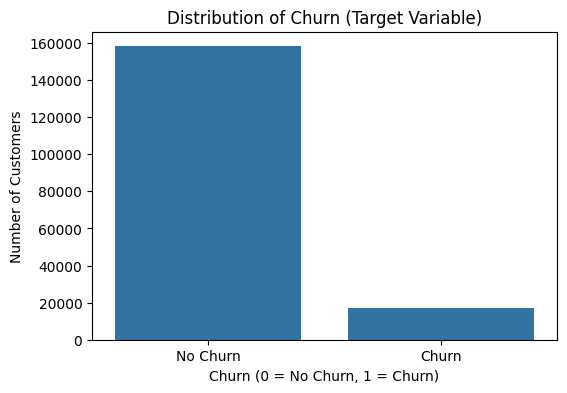

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'churn' in merged_df.columns:
    plt.figure(figsize=(6, 4))
    sns.countplot(x='churn', data=merged_df)
    plt.title('Distribution of Churn (Target Variable)')
    plt.xlabel('Churn (0 = No Churn, 1 = Churn)')
    plt.ylabel('Number of Customers')
    plt.xticks([0, 1], ['No Churn', 'Churn'])
    plt.show()
else:
    print("The 'churn' column was not found in the merged_df.")

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_stacked_bars(dataframe, category, churn_data=None):
    if churn_data is None:
        churn_data = dataframe['churn']

    # Group by category and churn, then count occurrences
    grouped_data = dataframe.groupby([category, churn_data]).size().unstack(fill_value=0)

    # Calculate percentages
    total_per_category = grouped_data.sum(axis=1)
    # Fill any NaN values that might arise if a category has no churn/no-no-churn
    percentage_data = grouped_data.divide(total_per_category, axis=0) * 100
    percentage_data = percentage_data.fillna(0)

    # Define custom colors: lighter purple for 'No Churn', bright orange for 'Churn'
    custom_colors = ['#9370DB', '#fdb863'] # Lighter purple for No Churn

    # Ensure the columns are in order (0, 1) for consistent color mapping
    # If only one type of churn exists for a category, unstack might not create both columns
    plot_columns = []
    if 0 in percentage_data.columns: plot_columns.append(0)
    if 1 in percentage_data.columns: plot_columns.append(1)

    ax = percentage_data[plot_columns].plot(kind='bar', stacked=True, figsize=(12, 7), color=custom_colors)
    plt.title(f'Churn Distribution by {category}')
    plt.xlabel(category)
    plt.ylabel('Percentage of Customers')
    plt.xticks(rotation=45, ha='right')

    # Update legend labels to match actual data and colors
    handles, labels = ax.get_legend_handles_labels()
    new_labels = []
    if '0' in labels: new_labels.append('No Churn')
    if '1' in labels: new_labels.append('Churn')
    plt.legend(handles, new_labels, title='Churn')

    # Add percentages on top of bars with improved visibility for small 'Churn' bars
    for i, container in enumerate(ax.containers):
        # i=0 for 'No Churn' bars, i=1 for 'Churn' bars
        for bar in container:
            height = bar.get_height()
            if height > 0:
                x = bar.get_x() + bar.get_width() / 2
                if i == 1: # Churn bars
                    # Place label above the bar if it's very small, otherwise center
                    if height < 5: # Threshold for small bars (e.g., less than 5%)
                        y_pos = bar.get_y() + height + 0.5 # Place just above the bar
                        va_align = 'bottom'
                    else:
                        y_pos = bar.get_y() + height / 2 # Center within the bar
                        va_align = 'center'
                    ax.text(x, y_pos, f'{height:.1f}%', ha='center', va=va_align,
                            fontsize=8, color='black', weight='bold') # Black for visibility on light orange
                else: # No Churn bars
                    ax.text(x, bar.get_y() + height / 2, f'{height:.1f}%', ha='center', va='center',
                            fontsize=8, color='black', weight='bold') # Use black for better contrast on lighter purple

    plt.tight_layout()
    plt.show()

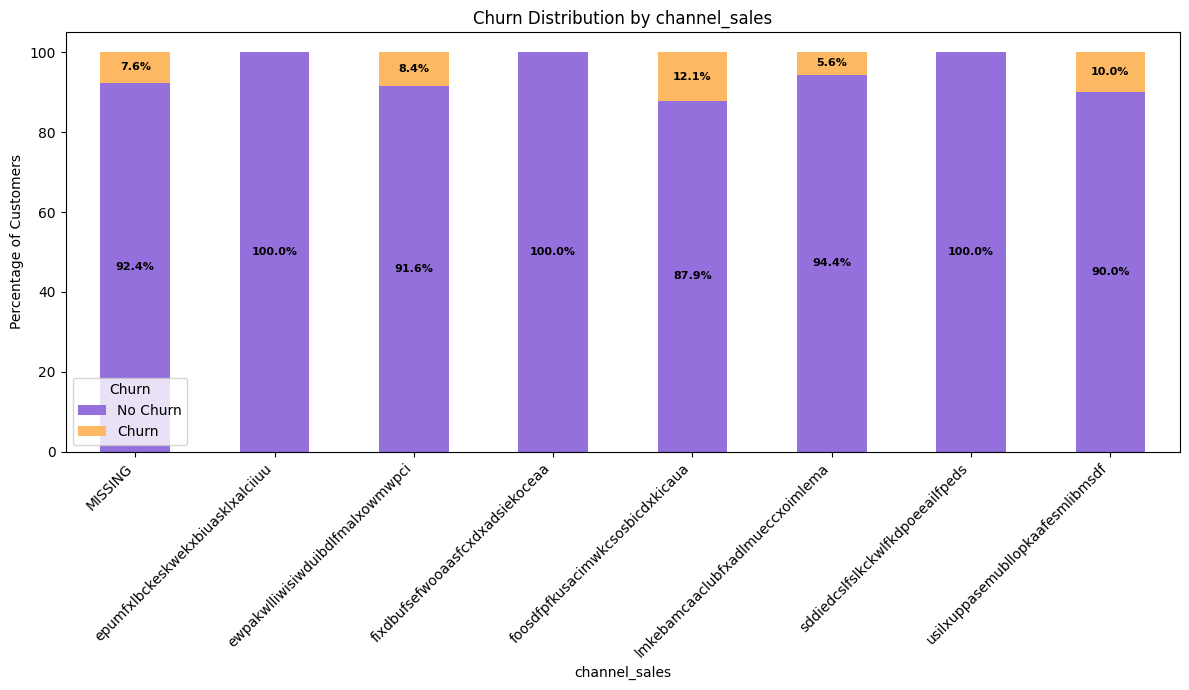

In [27]:
plot_stacked_bars(merged_df, 'channel_sales')

In [28]:
# Calculate mean and standard deviation for price components
price_features = price_df.groupby('id').agg(
    mean_price_off_peak_var=('price_off_peak_var', 'mean'),
    std_price_off_peak_var=('price_off_peak_var', 'std'),
    mean_price_peak_var=('price_peak_var', 'mean'),
    std_price_peak_var=('price_peak_var', 'std'),
    mean_price_mid_peak_var=('price_mid_peak_var', 'mean'),
    std_price_mid_peak_var=('price_mid_peak_var', 'std'),
    mean_price_off_peak_fix=('price_off_peak_fix', 'mean'),
    std_price_off_peak_fix=('price_off_peak_fix', 'std'),
    mean_price_peak_fix=('price_peak_fix', 'mean'),
    std_price_peak_fix=('price_peak_fix', 'std'),
    mean_price_mid_peak_fix=('price_mid_peak_fix', 'mean'),
    std_price_mid_peak_fix=('price_mid_peak_fix', 'std')
).reset_index()

# Display the new price features
display(price_features.head())

,id,mean_price_off_peak_var,std_price_off_peak_var,mean_price_peak_var,std_price_peak_var,mean_price_mid_peak_var,std_price_mid_peak_var,mean_price_off_peak_fix,std_price_off_peak_fix,mean_price_peak_fix,std_price_peak_fix,mean_price_mid_peak_fix,std_price_mid_peak_fix
0,0002203ffbb812588b632b9e628cc38d,0.124338,0.003976,0.103794,0.001989,0.073160,0.001368,40.701732,6.341481e-02,24.421038,0.038049,16.280694,0.025366
1,0004351ebdd665e6ee664792efc4fd13,0.146426,0.002197,0.000000,0.000000,0.000000,0.000000,44.385450,8.753223e-02,0.000000,0.000000,0.000000,0.000000
2,0010bcc39e42b3c2131ed2ce55246e3c,0.181558,0.026008,0.000000,0.000000,0.000000,0.000000,45.319710,7.723930e-01,0.000000,0.000000,0.000000,0.000000
3,0010ee3855fdea87602a5b7aba8e42de,0.118757,0.005049,0.098292,0.002580,0.069032,0.000403,40.647427,8.507958e-02,24.388455,0.051048,16.258971,0.034032
4,00114d74e963e47177db89bc70108537,0.147926,0.002202,0.000000,0.000000,0.000000,0.000000,44.266930,5.908392e-07,0.000000,0.000000,0.000000,0.000000


In [29]:
# Merge these new price features into merged_df
merged_df = pd.merge(merged_df, price_features, on='id', how='left')

print(f"Shape of merged_df after adding price features: {merged_df.shape}")
display(merged_df.head())

Shape of merged_df after adding price features: (175149, 88)


,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,mean_price_peak_var,std_price_peak_var,mean_price_mid_peak_var,std_price_mid_peak_var,mean_price_off_peak_fix,std_price_off_peak_fix,mean_price_peak_fix,std_price_peak_fix,mean_price_mid_peak_fix,std_price_mid_peak_fix
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.0,...,0.100749,0.005126,0.06653,0.020983,40.942265,1.050136,22.35201,7.039226,14.90134,4.692817
1,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.0,...,0.100749,0.005126,0.06653,0.020983,40.942265,1.050136,22.35201,7.039226,14.90134,4.692817
2,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.0,...,0.100749,0.005126,0.06653,0.020983,40.942265,1.050136,22.35201,7.039226,14.90134,4.692817
3,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.0,...,0.100749,0.005126,0.06653,0.020983,40.942265,1.050136,22.35201,7.039226,14.90134,4.692817
4,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.0,...,0.100749,0.005126,0.06653,0.020983,40.942265,1.050136,22.35201,7.039226,14.90134,4.692817


In [30]:
# Create new consumption-related features

# Average monthly consumption for electricity and gas
merged_df['avg_consumption_monthly_elec'] = merged_df['cons_12m'] / 12
merged_df['avg_consumption_monthly_gas'] = merged_df['cons_gas_12m'] / 12

# Consumption growth rate for electricity (from last month to 12m average)
# Handle potential division by zero by replacing 0s with a small epsilon or NaN
merged_df['consumption_growth_rate_elec'] = (merged_df['cons_last_month'] - merged_df['avg_consumption_monthly_elec']) / merged_df['avg_consumption_monthly_elec']
merged_df['consumption_growth_rate_elec'] = merged_df['consumption_growth_rate_elec'].replace([float('inf'), -float('inf')], pd.NA).fillna(0)

# Ratio of forecasted vs actual 12m consumption
merged_df['forecast_vs_actual_ratio_elec'] = merged_df['forecast_cons_12m'] / merged_df['cons_12m']
merged_df['forecast_vs_actual_ratio_elec'] = merged_df['forecast_vs_actual_ratio_elec'].replace([float('inf'), -float('inf')], pd.NA).fillna(0)


print(f"Shape of merged_df after adding consumption features: {merged_df.shape}")
display(merged_df[['id', 'avg_consumption_monthly_elec', 'avg_consumption_monthly_gas', 'consumption_growth_rate_elec', 'forecast_vs_actual_ratio_elec']].head())

Shape of merged_df after adding consumption features: (175149, 92)


/tmp/ipykernel_2038/94621787.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  merged_df['forecast_vs_actual_ratio_elec'] = merged_df['forecast_vs_actual_ratio_elec'].replace([float('inf'), -float('inf')], pd.NA).fillna(0)


,id,avg_consumption_monthly_elec,avg_consumption_monthly_gas,consumption_growth_rate_elec,forecast_vs_actual_ratio_elec
0,24011ae4ebbe3035111d65fa7c15bc57,0.0,4578.833333,0.0,0.0
1,24011ae4ebbe3035111d65fa7c15bc57,0.0,4578.833333,0.0,0.0
2,24011ae4ebbe3035111d65fa7c15bc57,0.0,4578.833333,0.0,0.0
3,24011ae4ebbe3035111d65fa7c15bc57,0.0,4578.833333,0.0,0.0
4,24011ae4ebbe3035111d65fa7c15bc57,0.0,4578.833333,0.0,0.0


## Feature Selection: Identifying Top Features with Random Forest

To identify the most influential features for predicting churn, we will use a Random Forest Classifier. Random Forests can inherently rank features based on their contribution to reducing impurity (Gini impurity or information gain).

First, we need to prepare our `merged_df` for machine learning by encoding categorical variables and separating features from the target variable.

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Drop 'id' column as it's just an identifier and not a feature
X = merged_df.drop(columns=['id', 'churn'])
y = merged_df['churn']

# Identify and drop datetime columns
datetime_cols = X.select_dtypes(include=['datetime64']).columns
X = X.drop(columns=datetime_cols)

# Identify categorical columns for one-hot encoding
categorical_cols = X.select_dtypes(include=['object']).columns

# Apply one-hot encoding to categorical features
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Handle any remaining non-numeric columns that might have slipped through (e.g., object type that isn't datetime or simple categorical)
# Convert remaining non-numeric columns (if any) to numeric, coercing errors to NaN
for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = pd.to_numeric(X[col], errors='coerce')

# Fill any remaining NaN values that might result from previous steps (e.g., one-hot encoding or coercion)
# A simple strategy is to fill with the mean/median, or 0 if appropriate for the data context.
X = X.fillna(X.mean())

# Ensure all columns are numeric
for col in X.columns:
    if X[col].dtype == 'bool': # Convert boolean columns to int
        X[col] = X[col].astype(int)

print(f"Shape of X after encoding and dropping datetime columns: {X.shape}")
display(X.head())

Shape of X after encoding and dropping datetime columns: (175149, 95)


,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,...,channel_sales_foosdfpfkusacimwkcsosbicdxkicaua,channel_sales_lmkebamcaaclubfxadlmueccxoimlema,channel_sales_sddiedcslfslkckwlfkdpoeeailfpeds,channel_sales_usilxuppasemubllopkaafesmlibmsdf,has_gas_t,origin_up_ewxeelcelemmiwuafmddpobolfuxioce,origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws,origin_up_ldkssxwpmemidmecebumciepifcamkci,origin_up_lxidpiddsbxsbosboudacockeimpuepw,origin_up_usapbepcfoloekilkwsdiboslwaxobdp
0,0,54946,0,0.0,0,0.0,1.78,0.114481,0.098142,40.606701,...,1,0,0,0,1,0,0,0,1,0
1,0,54946,0,0.0,0,0.0,1.78,0.114481,0.098142,40.606701,...,1,0,0,0,1,0,0,0,1,0
2,0,54946,0,0.0,0,0.0,1.78,0.114481,0.098142,40.606701,...,1,0,0,0,1,0,0,0,1,0
3,0,54946,0,0.0,0,0.0,1.78,0.114481,0.098142,40.606701,...,1,0,0,0,1,0,0,0,1,0
4,0,54946,0,0.0,0,0.0,1.78,0.114481,0.098142,40.606701,...,1,0,0,0,1,0,0,0,1,0


Now that our features are prepared, we will split the data into training and testing sets and then train a Random Forest Classifier to determine feature importances.


Top 20 Features for Churn Prediction:


,0
margin_net_pow_ele,0.034385
margin_net_pow_ele_mean,0.033503
margin_gross_pow_ele,0.031635
forecast_vs_actual_ratio_elec,0.030330
forecast_meter_rent_12m,0.029744
total_usage_12m,0.028070
cons_12m,0.027421
actual_vs_forecast_diff,0.027131
avg_consumption_monthly_elec,0.027125
net_margin,0.026500


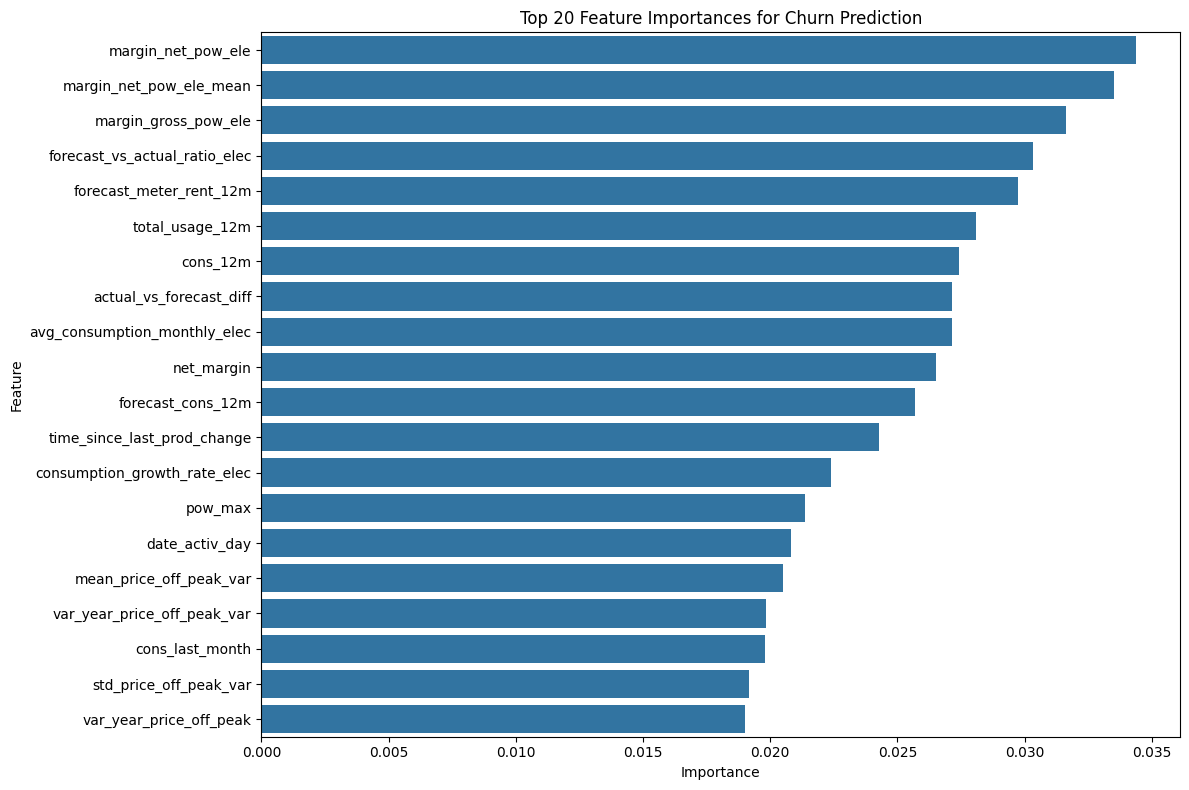

In [34]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Initialize and train a Random Forest Classifier
# Using class_weight='balanced' to help with the class imbalance observed earlier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)
rf_model.fit(X_train, y_train)

# Get feature importances
feature_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)

# Sort features by importance and select the top N (e.g., top 20)
top_features = feature_importances.nlargest(20)

print("\nTop 20 Features for Churn Prediction:")
display(top_features)

# Visualize the top features
plt.figure(figsize=(12, 8))
sns.barplot(x=top_features.values, y=top_features.index)
plt.title('Top 20 Feature Importances for Churn Prediction')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Feature Set Refinement

Based on the Random Forest feature importances, we will now select only the top 20 features to create a refined feature set. This can help improve model performance by reducing noise and potentially speeding up training.

In [36]:
# Select only the top 20 features from the original X DataFrame
X_refined = X[top_features.index]

print(f"Shape of X_refined (top 20 features): {X_refined.shape}")
display(X_refined.head())

Shape of X_refined (top 20 features): (175149, 20)


,margin_net_pow_ele,margin_net_pow_ele_mean,margin_gross_pow_ele,forecast_vs_actual_ratio_elec,forecast_meter_rent_12m,total_usage_12m,cons_12m,actual_vs_forecast_diff,avg_consumption_monthly_elec,net_margin,forecast_cons_12m,time_since_last_prod_change,consumption_growth_rate_elec,pow_max,date_activ_day,mean_price_off_peak_var,var_year_price_off_peak_var,cons_last_month,std_price_off_peak_var,var_year_price_off_peak
0,25.44,25.44,25.44,0.0,1.78,54946,0,0.0,0.0,678.99,0.0,-131,0.0,43.648,15,0.124787,0.000061,0,0.007829,1.102846
1,25.44,25.44,25.44,0.0,1.78,54946,0,0.0,0.0,678.99,0.0,-131,0.0,43.648,15,0.124787,0.000061,0,0.007829,1.102846
2,25.44,25.44,25.44,0.0,1.78,54946,0,0.0,0.0,678.99,0.0,-131,0.0,43.648,15,0.124787,0.000061,0,0.007829,1.102846
3,25.44,25.44,25.44,0.0,1.78,54946,0,0.0,0.0,678.99,0.0,-131,0.0,43.648,15,0.124787,0.000061,0,0.007829,1.102846
4,25.44,25.44,25.44,0.0,1.78,54946,0,0.0,0.0,678.99,0.0,-131,0.0,43.648,15,0.124787,0.000061,0,0.007829,1.102846


Now that our features are prepared, we will split the data into training and testing sets and then train a Random Forest Classifier to determine feature importances.

These new price features (mean and standard deviation of variable and fixed prices) are now added to our `merged_df`. They provide a summarized view of the pricing behavior each customer has experienced over time. We can now consider further feature engineering, such as creating consumption-related features or interaction features.